# Sim Combinations - averaging together power spectra

- If you average together the power spectra and fit a spectral model, what is the resultant exponent? How does it relate to the simulated value(s)

### Imports

In [1]:
# Import required functionality

import numpy as np #Imports numpy and then shortens its name

from neurodsp.utils import create_times # this allows us to create a time axis for our signal
from neurodsp.sim import sim_powerlaw, sim_oscillation, sim_combined, set_random_seed # these allow us to simulate a time series
from neurodsp.spectral import compute_spectrum_welch # this allows us to compute power spectra
from neurodsp.plts import plot_time_series, plot_power_spectra # these allow us to plot time series and spectra

from specparam import SpectralModel #This allows us to initialise and fit spectral models
from specparam.plts import plot_spectra # Plot one or multiple power spectra

from matplotlib import pyplot

### Data Simulation Settings

In [3]:
# Define simulation settings
n_seconds = 8
s_rate = 900

times = create_times(n_seconds, s_rate)
n_points = len(times)

### White, pink and brown noise - average power spectra


	Lower bounds below frequency-resolution have no effect (effective lower bound is the frequency resolution).
	Too low a limit may lead to overfitting noise as small bandwidth peaks.
	We recommend a lower bound of approximately 2x the frequency resolution.

Aperiodic parameters: 
 [-1.1315198   1.09649748] 



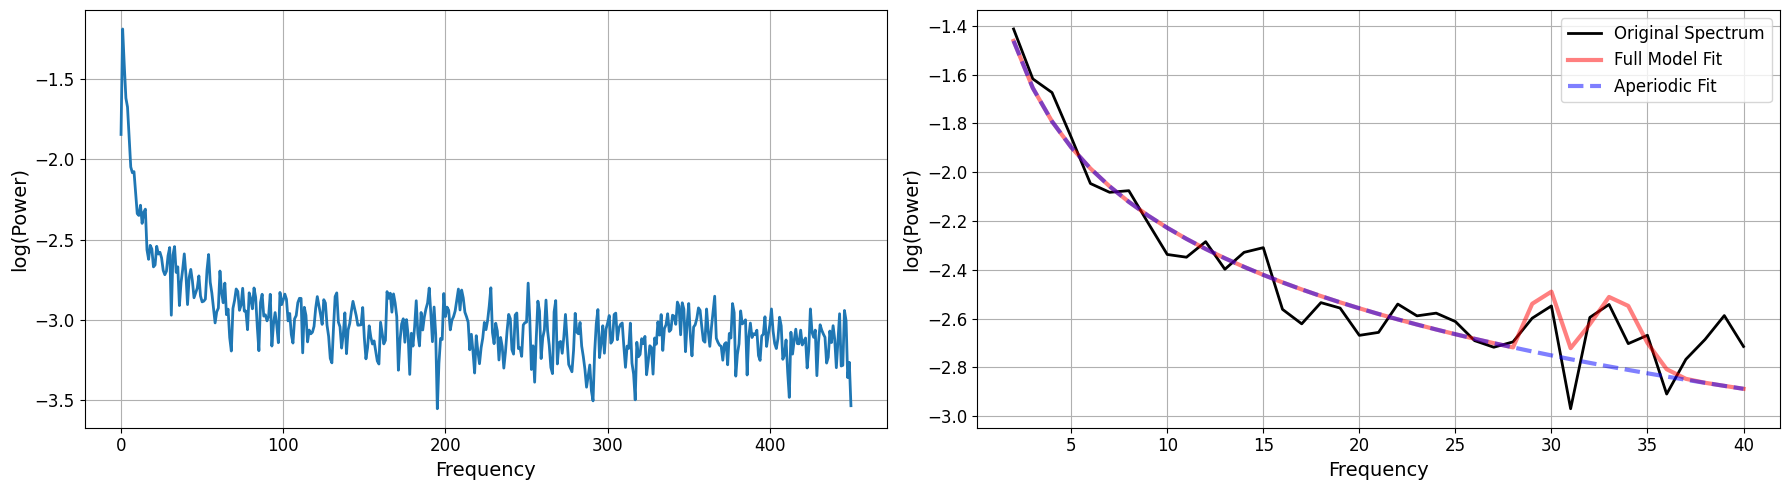

In [4]:
# Simulate signals
white_signal = np.random.normal(0, 1, n_points)
pink_signal = sim_powerlaw(n_seconds, s_rate, exponent=-1)
brown_signal = sim_powerlaw(n_seconds, s_rate, exponent=-2)

# Compute individual power spectra
w_freqs, w_powers = compute_spectrum_welch(white_signal, s_rate)
p_freqs, p_powers = compute_spectrum_welch(pink_signal, s_rate)
b_freqs, b_powers = compute_spectrum_welch(brown_signal, s_rate)

# Combine frequencies and powers in an array
freqs_stack = np.array([w_freqs, p_freqs, b_freqs])
powers_stack = np.array([w_powers, p_powers, b_powers])

# Calculate average for frequencies and powers
avg_freqs = np.mean(freqs_stack, axis=0)
avg_powers = np.mean(powers_stack, axis=0)

# Settings for plotting figures horizontally
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(18,5))

# Plot the average power spectra
plot_spectra(avg_freqs, avg_powers, log_powers=True, ax=ax1)

# Initialise Spectral Model
fm = SpectralModel()#

# Set frequency range
freq_range = [2,40]

# Fit and plot model
fm.fit(avg_freqs, avg_powers, freq_range)
fm.plot(ax=ax2)

# Print aperiodic offset and exponent 
print ('Aperiodic parameters: \n', fm.results.params.aperiodic.params, '\n')

**Comments**
- Exponent most closely reflects that of pink noise